In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import requests
import ast
import math

In [2]:
correct_pairs = {
    "H2CA36439": "C00502575",
    "H2NV04011": "C00668228",
    "H2OH13264": "C00801274",
    "H2OH16044": "C00864579",
    "H2OR06066": "C00793703",
    "H2PA17079": "C00509968",
    "H2TN07103": "C00614826",
    "H4CA35031": "C00557652",
    "H4NY22051": "C00632828",
    "H6DE00206": "C00590778",
    "H6OH04082": "C00416594",
    "H8NY06048": "C00430991",
    "H8UT03238": "C00647339",
    "S0FL00338": "C00458844",
    "S2PA00661": "C00851980",
    "S2WI00268": "C00870139",
    "S4OH00192": "C00837484"
}
correct_pairs = pd.DataFrame(list(correct_pairs.items()), columns = ["CAND_ID", "CAND_CMTE"])
outer_territory = ["PR", "GU"]

In [ ]:
def prefix_priority(val):
    if isinstance(val, str):
        if val.startswith("S"):
            return 0
        elif val.startswith("H"):
            return 1
    return 2

def get_pac_cand_matrix(df):
    return pd.crosstab(df["CMTE_ID"], df["CAND_ID"]).gt(0).astype(int)

def get_pac_party_matrix(df):
    return pd.crosstab(df["CMTE_ID"], df["CAND_PTY_AFFILIATION"]).gt(0).astype(int)

def count_shared_pacs(matrix):
    return (matrix.sum(axis=1) > 1).sum()

def safe_literal_eval(val):
    if pd.isna(val):
        return None
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return None

In [4]:
def get_district(id):
    return id.strip()[4:6]

def get_office(id):
    return id.strip()[0]

def count_unique(x):
    return len(set(x))

def is_committee(id):
    return id.strip()[0] == "C"

def hii(x):
    x = np.asarray(x)
    if x.sum() == 0:
        return None
    p = x / x.sum()
    return np.sum(p ** 2)

def is_open_seat(x):
    if ("I" not in x.values):
        return "O"
    if ("O" in x.values) & ("C" in x.values):
        return "UK"
    elif "O" in x.values:
        return "O"
    else:
        return "R"
    
def get_retired_incumbents(group):
    if {"O", "I"}.issubset(set(group["CAND_ICI"])):
        return group[group["CAND_ICI"] == "I"].index
    return pd.Index([]) 

In [5]:
base_url = "https://api.open.fec.gov/v1/"
def get_principal_committee(candidate):
    cand_url = f"{base_url}candidate/{candidate}/committees/"
    params = {"designation": "P",
              "api_key": "TRBP8kYWE0qWvUBU9XTtVdq43zvHHowWhNNIqwTc"}
    response = requests.get(cand_url, params=params).json()
    results = response.get("results", None)
    if not results:
        return None
    else:
        return results[0].get("committee_id", None)

In [33]:
candidates = pd.read_parquet("../data/candidates/candidate_master_2024.parquet")

In [34]:
contrib = pd.read_csv("../data/contributions/committees/corp_candidate_2024.csv")
corporate_pac = pd.read_csv("../data/cpac/corporate_pacs_2004_2024.csv")
cpac = corporate_pac[corporate_pac["YEAR"] == 2024].reset_index(drop=True)
cpac_id = cpac["CMTE_ID"].tolist()
cpac_contrib = contrib[contrib["CMTE_ID"].isin(cpac_id)].reset_index(drop=True)
cpac_contrib = cpac_contrib[cpac_contrib["TRANSACTION_AMT"] > 0]
cpac_contrib = cpac_contrib[cpac_contrib["YEAR"] == 2024].reset_index(drop=True)

C:\Users\zih028\AppData\Local\Temp\ipykernel_7460\285332141.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib = pd.read_csv("../data/contributions/committees/corp_candidate_2024.csv")


In [37]:
contrib_cand_cmte = cpac_contrib[["CAND_ID", "OTHER_ID"]].drop_duplicates()
contrib_cand_cmte = contrib_cand_cmte[contrib_cand_cmte["OTHER_ID"].apply(is_committee)]
cand_cand_cmte = candidates[["CAND_ID", "CAND_PCC", "CAND_ELECTION_YR"]].drop_duplicates()
contrib_cand_cmte = contrib_cand_cmte.merge(cand_cand_cmte[["CAND_ID", "CAND_PCC"]], how = "left",
                                            left_on = "OTHER_ID", right_on = "CAND_PCC",
                                            suffixes = ("", "_new"))
contrib_cand_cmte["CAND_ID"] = contrib_cand_cmte["CAND_ID"].fillna(contrib_cand_cmte["CAND_ID_new"])
contrib_cand_cmte.drop(columns = ["CAND_ID_new", "CAND_PCC"], inplace=True)
cand_cmte = pd.merge(contrib_cand_cmte, cand_cand_cmte,
                     how = "outer", on = "CAND_ID",
                     suffixes = ("_contrib", "_cand"))

In [38]:
cand_cmte = cand_cmte.dropna(subset="OTHER_ID")
cand_cmte = cand_cmte.merge(correct_pairs, how = "left", on = "CAND_ID")
cand_cmte["CAND_CMTE"] = cand_cmte["CAND_CMTE"].fillna(cand_cmte["CAND_PCC"])
cand_cmte.drop(columns = ["OTHER_ID", "CAND_PCC"], inplace=True)
cand_cmte = cand_cmte.dropna(subset = "CAND_CMTE")
cand_cmte = cand_cmte.drop_duplicates()

In [40]:
candidates = candidates.merge(cand_cmte.drop(columns="CAND_ELECTION_YR"), how = "left", on = "CAND_ID")
candidates["CAND_CMTE"] = candidates["CAND_CMTE"].fillna(candidates["CAND_PCC"])
candidates.drop(columns="CAND_PCC", inplace = True)

In [42]:
cand_cmte_2024 = cand_cmte[cand_cmte["CAND_ELECTION_YR"] >= 2024].copy()
cand_cmte_2024["priority"] = cand_cmte_2024["CAND_ID"].apply(prefix_priority)
cand_cmte_2024 = cand_cmte_2024.sort_values(by = "priority")
cand_cmte_2024 = cand_cmte_2024.drop_duplicates(subset = "CAND_CMTE", keep="first")
cand_cmte_2024.drop(columns = ["CAND_ELECTION_YR", "priority"], inplace = True)

In [43]:
cand_cmte_2024

,CAND_ID,CAND_CMTE
780,S8WA00194,C00349506
659,S2MT00096,C00491357
661,S2NC00307,C00543231
663,S2NC00505,C00614776
665,S2NE00094,C00498907
...,...,...
261,H2VA02064,C00776120
262,H2VA07170,C00791574
263,H2VI00082,C00528182
286,H4CA16239,C00858969


In [47]:
cpac_contrib = cpac_contrib.merge(cand_cmte_2024, how = "left", left_on = "OTHER_ID", right_on = "CAND_CMTE",
                                  suffixes = ("_old", ""))
cpac_contrib.drop(columns=["CAND_ID_old", "CAND_CMTE"], inplace=True)
cpac_contrib = cpac_contrib.dropna(subset="CAND_ID").reset_index(drop=True)

In [48]:
house = candidates[(candidates["CAND_OFFICE"] == "H")].copy()
house["CAND_OFFICE_DISTRICT"] = house["CAND_OFFICE_DISTRICT"].fillna(house["CAND_ID"].apply(get_district)).astype(int)
house = house.sort_values(by=["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"]).dropna(subset="CAND_CMTE").reset_index(drop=True)

In [49]:
cpac_house = cpac_contrib[cpac_contrib["CAND_ID"].apply(get_office) == "H"].reset_index(drop=True)

In [50]:
house_funded = cpac_house.copy()
house_funded = house_funded.groupby("CAND_ID", as_index=False).agg({"TRANSACTION_AMT":"sum",
                                                                   "SUB_ID": "count",
                                                                   "CMTE_ID": count_unique})
house_funded = pd.merge(house.drop(columns=["CAND_CMTE", "CAND_ST1", "CAND_ST2", "CAND_CITY", "CAND_ST", "CAND_ZIP"],),
                        house_funded,
                        how = "right", on = "CAND_ID")
house_seats = (
    house_funded
    .groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"], as_index=False)["CAND_ICI"]
    .agg(is_open_seat)
    .rename(columns={"CAND_ICI":"SEAT_TYPE"})
)
retired_incumbents_idx = house_funded.groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"]).apply(get_retired_incumbents).explode().dropna()
retired_incumbents = house_funded.loc[retired_incumbents_idx, ["CAND_ID", "CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"]]

C:\Users\zih028\AppData\Local\Temp\ipykernel_7460\379147015.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  retired_incumbents_idx = house_funded.groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"]).apply(get_retired_incumbents).explode().dropna()


In [51]:
cpac_house = cpac_house[~cpac_house["CAND_ID"].isin(retired_incumbents["CAND_ID"])]

In [52]:
house_contrib_unique = pd.merge(house[["CAND_ID", "CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"]],
                                cpac_house,
                                how = "outer", on = "CAND_ID").dropna(subset="CMTE_ID").groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"], as_index=False)[["CMTE_ID"]].agg(count_unique)
house_contrib_unique = house_contrib_unique.rename(columns={"CMTE_ID":"unique_total"})
house_contrib = cpac_house.groupby("CAND_ID", as_index=False).agg({"TRANSACTION_AMT":"sum",
                                                                   "SUB_ID": "count",
                                                                   "CMTE_ID": count_unique})
house_contrib = pd.merge(house.drop(columns=["CAND_CMTE", "CAND_ST1", "CAND_ST2", "CAND_CITY", "CAND_ST", "CAND_ZIP"],),
                         house_contrib,
                         how = "outer", on = "CAND_ID")
house_contrib[["TRANSACTION_AMT", "SUB_ID", "CMTE_ID"]] = house_contrib[["TRANSACTION_AMT", "SUB_ID", "CMTE_ID"]].fillna(0)
house_contrib = house_contrib.rename(columns = {"TRANSACTION_AMT": "amount",
                                      "SUB_ID": "count",
                                      "CMTE_ID": "unique"})
house_contrib = house_contrib.sort_values(by = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"]).reset_index(drop=True)

In [55]:
house_contrib_hii = house_contrib.groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"], as_index=False)[["amount", "count", "unique"]].agg(hii)
house_contrib_sum= house_contrib.groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"], as_index=False)[["amount", "count", "unique"]].agg("sum")

In [56]:
house_contrib_stats = pd.merge(house_contrib_hii, house_contrib_sum,
                               how = "left", on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"],
                               suffixes = ("_hii", "_sum")).merge(house_contrib_unique,
                                                                  how = "left", on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])

In [58]:
house_contrib

,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_ELECTION_YR,CAND_OFFICE_ST,CAND_OFFICE,CAND_OFFICE_DISTRICT,CAND_ICI,CAND_STATUS,amount,count,unique
0,H0AK00105,"LAMB, THOMAS",NNE,2020.0,AK,H,0,C,N,0.0,0.0,0.0
1,H2AK00200,"CONSTANT, CHRISTOPHER",DEM,2022.0,AK,H,0,C,P,0.0,0.0,0.0
2,H2AK00226,"PALIN, SARAH",REP,2022.0,AK,H,0,O,P,0.0,0.0,0.0
3,H2AK00242,"NOTTI, EMIL",DEM,2022.0,AK,H,0,O,N,0.0,0.0,0.0
4,H2AK00267,"ARMSTRONG, JAY R",W,2022.0,AK,H,0,O,N,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5419,H6WY00159,"CHENEY, ELIZABETH MRS.",REP,2022.0,WY,H,0,I,P,0.0,0.0,0.0
5420,H8WY00148,"LUMMIS, CYNTHIA MARIE",REP,2016.0,WY,H,0,I,P,0.0,0.0,0.0
5421,H8WY01054,"HELM, TRAVIS",DEM,2018.0,WY,H,0,C,N,0.0,0.0,0.0
5422,H8WY01062,"HUNTER, GREG",DEM,2018.0,WY,H,0,C,P,0.0,0.0,0.0


In [60]:
house_contrib_seats = pd.merge(house_contrib, house_seats,
                               how = "left", on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
house_contrib_seats["CAND_TYPE"] = house_contrib_seats["SEAT_TYPE"].apply(lambda x: x if pd.notna(x) and x == "O" else None)
house_contrib_seats["CAND_TYPE"] = house_contrib_seats["CAND_TYPE"].fillna(house_contrib_seats["CAND_ICI"])

house_top_receipt = (
    house_contrib_seats
    .sort_values("amount", ascending=False)
    .groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"], as_index=False)
    .agg({"CAND_TYPE": "first"})
    .rename(columns = {"CAND_TYPE": "TOP_CAND"})
)

In [61]:
house_contrib_stats = (
    house_contrib_stats
    .merge(house_seats, on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
    .merge(house_top_receipt, on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
)

In [35]:
house_contrib_stats.to_csv("../data/summary/house_contribution_2024.csv", index=False)

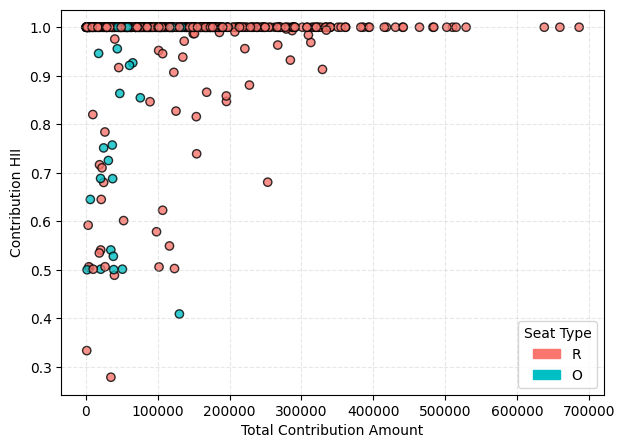

In [27]:
color_map = {
    "R": "#F8766D",
    "O": "#00BFC4",
}
colors = house_contrib_stats["SEAT_TYPE"].map(color_map)
plt.figure(figsize = (7, 5))
plt.scatter(house_contrib_stats["amount_sum"],
            house_contrib_stats["amount_hii"],
            color = colors,
            alpha = 0.8,
            edgecolor = "black")
plt.xlabel("Total Contribution Amount")
plt.ylabel("Contribution HII")
plt.grid(True, linestyle="--", alpha=0.3)
legend_handles = [mpatches.Patch(color=c, label=label) for label, c in color_map.items()]
plt.legend(handles=legend_handles, title="Seat Type", loc="lower right")
plt.show()

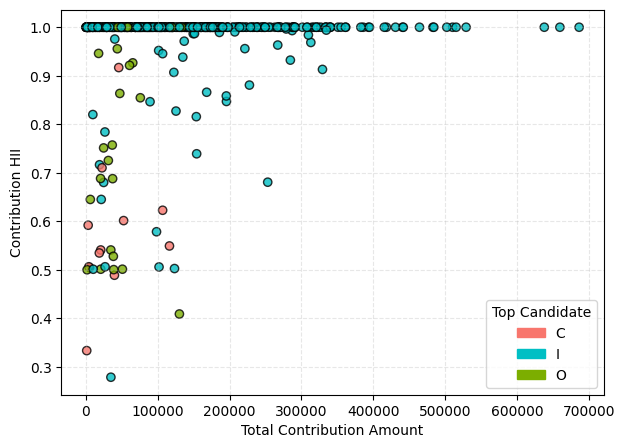

In [28]:
color_map = {
    "C": "#F8766D", # Red
    "I": "#00BFC4", # Blue 
    "O": "#7CAE00" # Green
}
colors = house_contrib_stats["TOP_CAND"].map(color_map)
plt.figure(figsize = (7, 5))
plt.scatter(house_contrib_stats["amount_sum"],
            house_contrib_stats["amount_hii"],
            color = colors,
            alpha = 0.8,
            edgecolor = "black")
plt.xlabel("Total Contribution Amount")
plt.ylabel("Contribution HII")
plt.grid(True, linestyle="--", alpha=0.3)
legend_handles = [mpatches.Patch(color=c, label=label) for label, c in color_map.items()]
plt.legend(handles=legend_handles, title="Top Candidate", loc="lower right")
plt.show()

In [62]:
compete = house_contrib_stats[house_contrib_stats["amount_hii"] < 1]
compete_cands = pd.merge(compete[["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT", "SEAT_TYPE", "TOP_CAND"]],
                            house_contrib,
                            how = "left", on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
compete_cands = compete_cands[compete_cands["amount"] > 0]
cpac_compete = cpac_house.merge(compete_cands[["CAND_ID", "CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"]],
                                how = "right", on = "CAND_ID")

In [69]:
house_contrib

,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_ELECTION_YR,CAND_OFFICE_ST,CAND_OFFICE,CAND_OFFICE_DISTRICT,CAND_ICI,CAND_STATUS,amount,count,unique
0,H0AK00105,"LAMB, THOMAS",NNE,2020.0,AK,H,0,C,N,0.0,0.0,0.0
1,H2AK00200,"CONSTANT, CHRISTOPHER",DEM,2022.0,AK,H,0,C,P,0.0,0.0,0.0
2,H2AK00226,"PALIN, SARAH",REP,2022.0,AK,H,0,O,P,0.0,0.0,0.0
3,H2AK00242,"NOTTI, EMIL",DEM,2022.0,AK,H,0,O,N,0.0,0.0,0.0
4,H2AK00267,"ARMSTRONG, JAY R",W,2022.0,AK,H,0,O,N,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5419,H6WY00159,"CHENEY, ELIZABETH MRS.",REP,2022.0,WY,H,0,I,P,0.0,0.0,0.0
5420,H8WY00148,"LUMMIS, CYNTHIA MARIE",REP,2016.0,WY,H,0,I,P,0.0,0.0,0.0
5421,H8WY01054,"HELM, TRAVIS",DEM,2018.0,WY,H,0,C,N,0.0,0.0,0.0
5422,H8WY01062,"HUNTER, GREG",DEM,2018.0,WY,H,0,C,P,0.0,0.0,0.0


In [30]:
pac_cand_matrix = {
    f"{st}-{district}": get_pac_cand_matrix(group)
    for (st, district), group in cpac_compete.groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
}

In [32]:
house_contrib_party = (
    house_contrib
    .groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT", "CAND_PTY_AFFILIATION"], as_index=False)[["amount", "count"]]
    .agg("sum")
)
house_contrib_party_hii = (
    house_contrib_party
    .groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"], as_index=False)[["amount", "count"]]
    .agg(hii)
)
house_contrib_party_sum = (
    house_contrib_party
    .groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"], as_index=False)[["amount", "count"]]
    .agg("sum")
)
house_contrib_party_stats = (
    pd
    .merge(house_contrib_party_hii, house_contrib_party_sum,
           how = "left", on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"],
           suffixes = ("_hii", "_sum"))
)
house_contrib_party_stats = (
    house_contrib_party_stats
    .merge(house_seats, on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
    .merge(house_top_receipt, on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
)

In [81]:
house_contrib_party_stats.to_csv("../data/summary/house_contribution_party_2024.csv", index=False)

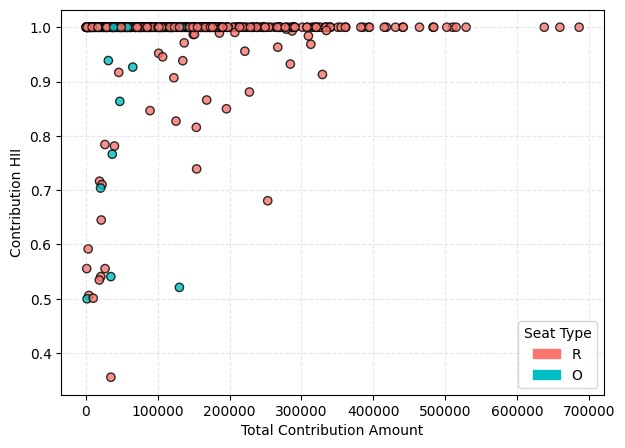

In [36]:
color_map = {
    "R": "#F8766D",
    "O": "#00BFC4",
}
colors = house_contrib_party_stats["SEAT_TYPE"].map(color_map)
plt.figure(figsize = (7, 5))
plt.scatter(house_contrib_party_stats["amount_sum"],
            house_contrib_party_stats["amount_hii"],
            color = colors,
            alpha = 0.8,
            edgecolor = "black")
plt.xlabel("Total Contribution Amount")
plt.ylabel("Contribution HII")
plt.grid(True, linestyle="--", alpha=0.3)
legend_handles = [mpatches.Patch(color=c, label=label) for label, c in color_map.items()]
plt.legend(handles=legend_handles, title="Seat Type", loc="lower right")
plt.show()

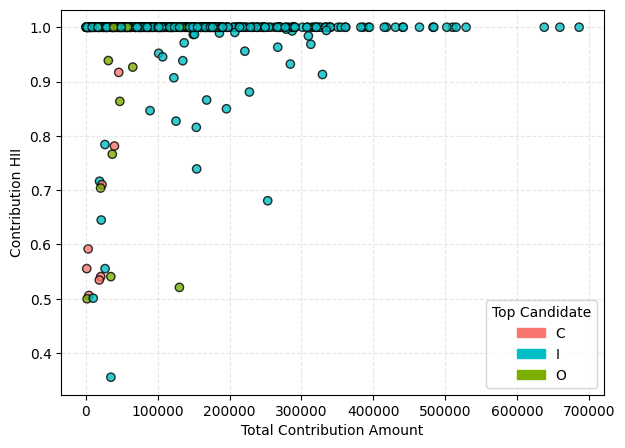

In [37]:
color_map = {
    "C": "#F8766D", # Red
    "I": "#00BFC4", # Blue 
    "O": "#7CAE00" # Green
}
colors = house_contrib_party_stats["TOP_CAND"].map(color_map)
plt.figure(figsize = (7, 5))
plt.scatter(house_contrib_party_stats["amount_sum"],
            house_contrib_party_stats["amount_hii"],
            color = colors,
            alpha = 0.8,
            edgecolor = "black")
plt.xlabel("Total Contribution Amount")
plt.ylabel("Contribution HII")
plt.grid(True, linestyle="--", alpha=0.3)
legend_handles = [mpatches.Patch(color=c, label=label) for label, c in color_map.items()]
plt.legend(handles=legend_handles, title="Top Candidate", loc="lower right")
plt.show()

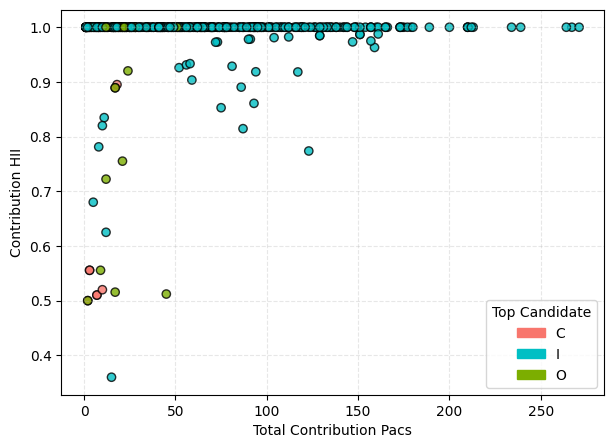

In [38]:
color_map = {
    "C": "#F8766D", # Red
    "I": "#00BFC4", # Blue 
    "O": "#7CAE00" # Green
}
colors = house_contrib_party_stats["TOP_CAND"].map(color_map)
plt.figure(figsize = (7, 5))
plt.scatter(house_contrib_party_stats["count_sum"],
            house_contrib_party_stats["count_hii"],
            color = colors,
            alpha = 0.8,
            edgecolor = "black")
plt.xlabel("Total Contribution Pacs")
plt.ylabel("Contribution HII")
plt.grid(True, linestyle="--", alpha=0.3)
legend_handles = [mpatches.Patch(color=c, label=label) for label, c in color_map.items()]
plt.legend(handles=legend_handles, title="Top Candidate", loc="lower right")
plt.show()

In [261]:
print(house_contrib_party_stats[house_contrib_party_stats["SEAT_TYPE"] == "O"]["amount_sum"].mean())
print(house_contrib_party_stats[house_contrib_party_stats["SEAT_TYPE"] == "R"]["amount_sum"].mean())


38118.5
151644.7667560322


In [41]:
party_compete = house_contrib_party_stats[house_contrib_party_stats["amount_hii"] < 1]
compete_party = pd.merge(party_compete[["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT", "SEAT_TYPE", "TOP_CAND"]],
                            house_contrib_party,
                            how = "left", on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
compete_party = compete_party[compete_party["amount"] > 0]

cpac_compete_party = (
    house_contrib
    .merge(compete_party[["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"]])
    .merge(cpac_house, on = "CAND_ID")
)

In [44]:
cpac_compete_party

,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_ELECTION_YR,CAND_OFFICE_ST,CAND_OFFICE,CAND_OFFICE_DISTRICT,CAND_ICI,CAND_STATUS,amount,...,TRANSACTION_AMT,OTHER_ID,TRAN_ID,FILE_NUM,MEMO_CD,MEMO_TEXT,SUB_ID,YEAR,MONTH,DAY
0,H2AK01083,"BEGICH, NICHOLAS III",REP,2024.0,AK,H,0,C,C,11000.0,...,5000.0,C00792341,3B675CB8B2556142E0B,1831227,NaN,NaN,4112620241073701847,2024,9,26
1,H2AK01083,"BEGICH, NICHOLAS III",REP,2024.0,AK,H,0,C,C,11000.0,...,5000.0,C00792341,1EDAB74CA909EF464F7,1835228,NaN,NaN,4112120241072155903,2024,10,12
2,H2AK01083,"BEGICH, NICHOLAS III",REP,2024.0,AK,H,0,C,C,11000.0,...,1000.0,C00792341,SB23.8093,1840257,NaN,NaN,4120220241074200633,2024,10,1
3,H2AK01083,"BEGICH, NICHOLAS III",REP,2024.0,AK,H,0,C,C,11000.0,...,5000.0,C00792341,3B675CB8B2556142E0B,1831227,NaN,NaN,4112620241073701847,2024,9,26
4,H2AK01083,"BEGICH, NICHOLAS III",REP,2024.0,AK,H,0,C,C,11000.0,...,5000.0,C00792341,1EDAB74CA909EF464F7,1835228,NaN,NaN,4112120241072155903,2024,10,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5974,H8WI01156,"STEIL, BRYAN GEORGE",REP,2024.0,WI,H,1,I,C,333500.0,...,1500.0,C00677286,BB88DA165D8F84C55A12,1835871,NaN,NaN,4112120241072141700,2024,10,11
5975,H8WI01156,"STEIL, BRYAN GEORGE",REP,2024.0,WI,H,1,I,C,333500.0,...,1500.0,C00677286,BFB4845288C7D444D905,1821007,NaN,NaN,4100820242069281207,2024,9,26
5976,H8WI01156,"STEIL, BRYAN GEORGE",REP,2024.0,WI,H,1,I,C,333500.0,...,3000.0,C00677286,C915D475C3513457B04,1821055,NaN,NaN,4100720242069225433,2024,9,25
5977,H8WI01156,"STEIL, BRYAN GEORGE",REP,2024.0,WI,H,1,I,C,333500.0,...,2500.0,C00677286,50738938,1820853,NaN,CONTRIBUTION,4100820242069282395,2024,9,23


In [46]:
pac_party_matrix = {
    f"{st}-{district}": get_pac_party_matrix(group)
    for (st, district), group in cpac_compete_party.groupby(["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
}

In [47]:
races = pac_party_matrix.keys()
pac_race = pd.DataFrame()
for race in races:
    pac_party = pac_party_matrix[race].reset_index()
    pac_cand = pac_cand_matrix[race]
    cand_ids = pac_cand.columns
    pac_cand["C"] = 0
    pac_cand["I"] = 0
    for col in cand_ids:
        cand_ici = house_contrib.loc[house_contrib["CAND_ID"] == col, "CAND_ICI"].values
        if "I" in cand_ici:
            pac_cand["I"] = pac_cand["I"] + pac_cand[col]
        elif "C" in cand_ici:
            pac_cand["C"] = pac_cand["C"] + pac_cand[col]
    pac_cand = pac_cand.reset_index()
    pac_race_stats = pac_party.merge(pac_cand[["CMTE_ID", "C", "I"]], how = "left", on = ["CMTE_ID"])
    pac_race_stats["STATE"] = race.split("-")[0]
    pac_race_stats["DISTRICT"] = race.split("-")[1]
    if len(pac_race) == 0:
        pac_race = pac_race_stats
    else:
        pac_race = pd.concat([pac_race, pac_race_stats])
pac_race = pac_race.fillna(0).reset_index(drop=True)

In [48]:
pac_race[["DEM", "REP", "C", "I", "NON", "NPP", "PNP"]] = pac_race[["DEM", "REP", "C", "I", "NON", "NPP", "PNP"]].map(
    lambda x: 1 if pd.notna(x) and float(x) > 0 else 0
)
pac_race["DISTRICT"] = pac_race["DISTRICT"].astype(int)
pac_race["MULT_PARTY"] = (pac_race["DEM"] + pac_race["REP"] + pac_race["NON"] + pac_race["NPP"] + pac_race["PNP"] > 1).astype(int)
pac_race["IC"] = (pac_race["C"] + pac_race["I"] > 1).astype(int)

In [49]:
pac_race = pac_race.merge(house_contrib_party_stats, how = "left",
                          left_on = ["STATE", "DISTRICT"], right_on = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"])
pac_race.drop(columns = ["CAND_OFFICE_ST", "CAND_OFFICE_DISTRICT"], inplace = True)

In [51]:
house_contrib_party_stats

,CAND_OFFICE_ST,CAND_OFFICE_DISTRICT,amount_hii,count_hii,amount_sum,count_sum,SEAT_TYPE,TOP_CAND
0,AK,0,0.849853,0.918515,195700.0,94.0,R,I
1,AL,1,1.000000,1.000000,102000.0,52.0,R,I
2,AL,2,0.520994,0.512099,130300.0,45.0,O,O
3,AL,3,1.000000,1.000000,180000.0,69.0,R,I
4,AL,4,1.000000,1.000000,173000.0,76.0,R,I
...,...,...,...,...,...,...,...,...
422,WI,7,1.000000,1.000000,29500.0,18.0,R,I
423,WI,8,1.000000,1.000000,39000.0,12.0,O,O
424,WV,1,1.000000,1.000000,277500.0,129.0,R,I
425,WV,2,1.000000,1.000000,58500.0,22.0,O,O


In [50]:
pac_race

,CMTE_ID,DEM,REP,C,I,STATE,DISTRICT,NON,NPP,PNP,MULT_PARTY,IC,amount_hii,count_hii,amount_sum,count_sum,SEAT_TYPE,TOP_CAND
0,C00008748,1,0,0,1,AK,0,0,0,0,0,0,0.849853,0.918515,195700.0,94.0,R,I
1,C00009282,1,0,0,1,AK,0,0,0,0,0,0,0.849853,0.918515,195700.0,94.0,R,I
2,C00010470,1,0,0,1,AK,0,0,0,0,0,0,0.849853,0.918515,195700.0,94.0,R,I
3,C00012245,1,0,0,1,AK,0,0,0,0,0,0,0.849853,0.918515,195700.0,94.0,R,I
4,C00024349,1,0,0,1,AK,0,0,0,0,0,0,0.849853,0.918515,195700.0,94.0,R,I
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2113,C00693390,0,1,0,1,WI,1,0,0,0,0,0,0.994039,0.987655,334500.0,161.0,R,I
2114,C00719393,0,1,0,1,WI,1,0,0,0,0,0,0.994039,0.987655,334500.0,161.0,R,I
2115,C00731000,0,1,0,1,WI,1,0,0,0,0,0,0.994039,0.987655,334500.0,161.0,R,I
2116,C00817395,0,1,0,1,WI,1,0,0,0,0,0,0.994039,0.987655,334500.0,161.0,R,I


In [142]:
pac_race[pac_race["I"] == 0]

,CMTE_ID,DEM,REP,C,I,STATE,DISTRICT,NON,NPP,PNP,...,IC,amount_hii,count_hii,unique_hii,amount_sum,count_sum,unique_sum,unique_total,SEAT_TYPE,TOP_CAND
9,C00040394,0,1,1,0,AK,0,0,0,0,...,0,0.846981,0.917836,0.884757,195700.0,94.0,66.0,66.0,R,I
37,C00236489,0,1,1,0,AK,0,0,0,0,...,0,0.846981,0.917836,0.884757,195700.0,94.0,66.0,66.0,R,I
38,C00238311,0,1,1,0,AK,0,0,0,0,...,0,0.846981,0.917836,0.884757,195700.0,94.0,66.0,66.0,R,I
54,C00438754,0,1,1,0,AK,0,0,0,0,...,0,0.846981,0.917836,0.884757,195700.0,94.0,66.0,66.0,R,I
66,C00009282,1,0,1,0,AL,2,0,0,0,...,0,0.408879,0.402469,0.381173,130300.0,45.0,36.0,26.0,O,O
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,C00475350,1,0,0,0,WA,6,0,0,0,...,0,0.725237,0.557093,0.539062,31550.0,17.0,16.0,15.0,O,O
2012,C00672790,1,0,0,0,WA,6,0,0,0,...,0,0.725237,0.557093,0.539062,31550.0,17.0,16.0,15.0,O,O
2013,C00820167,1,0,0,0,WA,6,0,0,0,...,0,0.725237,0.557093,0.539062,31550.0,17.0,16.0,15.0,O,O
2014,C00820670,1,0,0,0,WA,6,0,0,0,...,0,0.725237,0.557093,0.539062,31550.0,17.0,16.0,15.0,O,O


In [78]:
cpac_hedge = pd.read_csv("../data/hedging/cpac_hedging_2024.csv")
cpac_hedge = cpac_hedge[["CMTE_ID", "RIC", "TRBC_Econ_Sector", 'house_hedge_count', 'house_hedge_amount','house_balance_count', 'house_balance_amount', 'contribute_sum', 'n_states', 'n_cands']]
cpac_hedge["Sector"] = (
    cpac_hedge["TRBC_Econ_Sector"]
    .apply(safe_literal_eval)
    .apply(lambda x: x[0] if isinstance(x, list) else None)
)
cpac_hedge.drop(columns="TRBC_Econ_Sector", inplace=True)

In [79]:
pac_race_firm = (
    pac_race
    .merge(cpac_hedge,
           how = "left", on = "CMTE_ID")
)
pac_race_firm["race_id"] = pac_race_firm["STATE"].astype(str) + "-" + pac_race_firm["DISTRICT"].astype(str)

In [82]:
pac_race_firm.to_csv("../data/summary/house_compete_contribution_pac_2024.csv", index=False)

In [54]:
melted_party = pac_race_firm.melt(
    id_vars = ["CMTE_ID", "race_id", "Sector", "RIC", "house_hedge_count", "house_hedge_amount", "house_balance_count", "house_balance_amount"],
    value_vars = ["DEM", "REP"],
    var_name = "Party",
    value_name = "Supported"
)
melted_party = melted_party[melted_party["Supported"] == 1].reset_index(drop=True)

valid_races = (
    melted_party.groupby("race_id")["CMTE_ID"].nunique()
    .loc[lambda x: x>=5]
    .index
)

In [55]:
melted_party["Public"] = melted_party["RIC"].apply(lambda x: "Private" if pd.isna(x) else "Public")
melted_party["Balance"] = melted_party["house_balance_amount"].apply(
    lambda x: "REP Speculate" if x < -0.5 else "REP Hedge" if x < 0 else "DEM Hedge" if x < 0.5 else "Dem Speculate" if x <= 1 else None
)

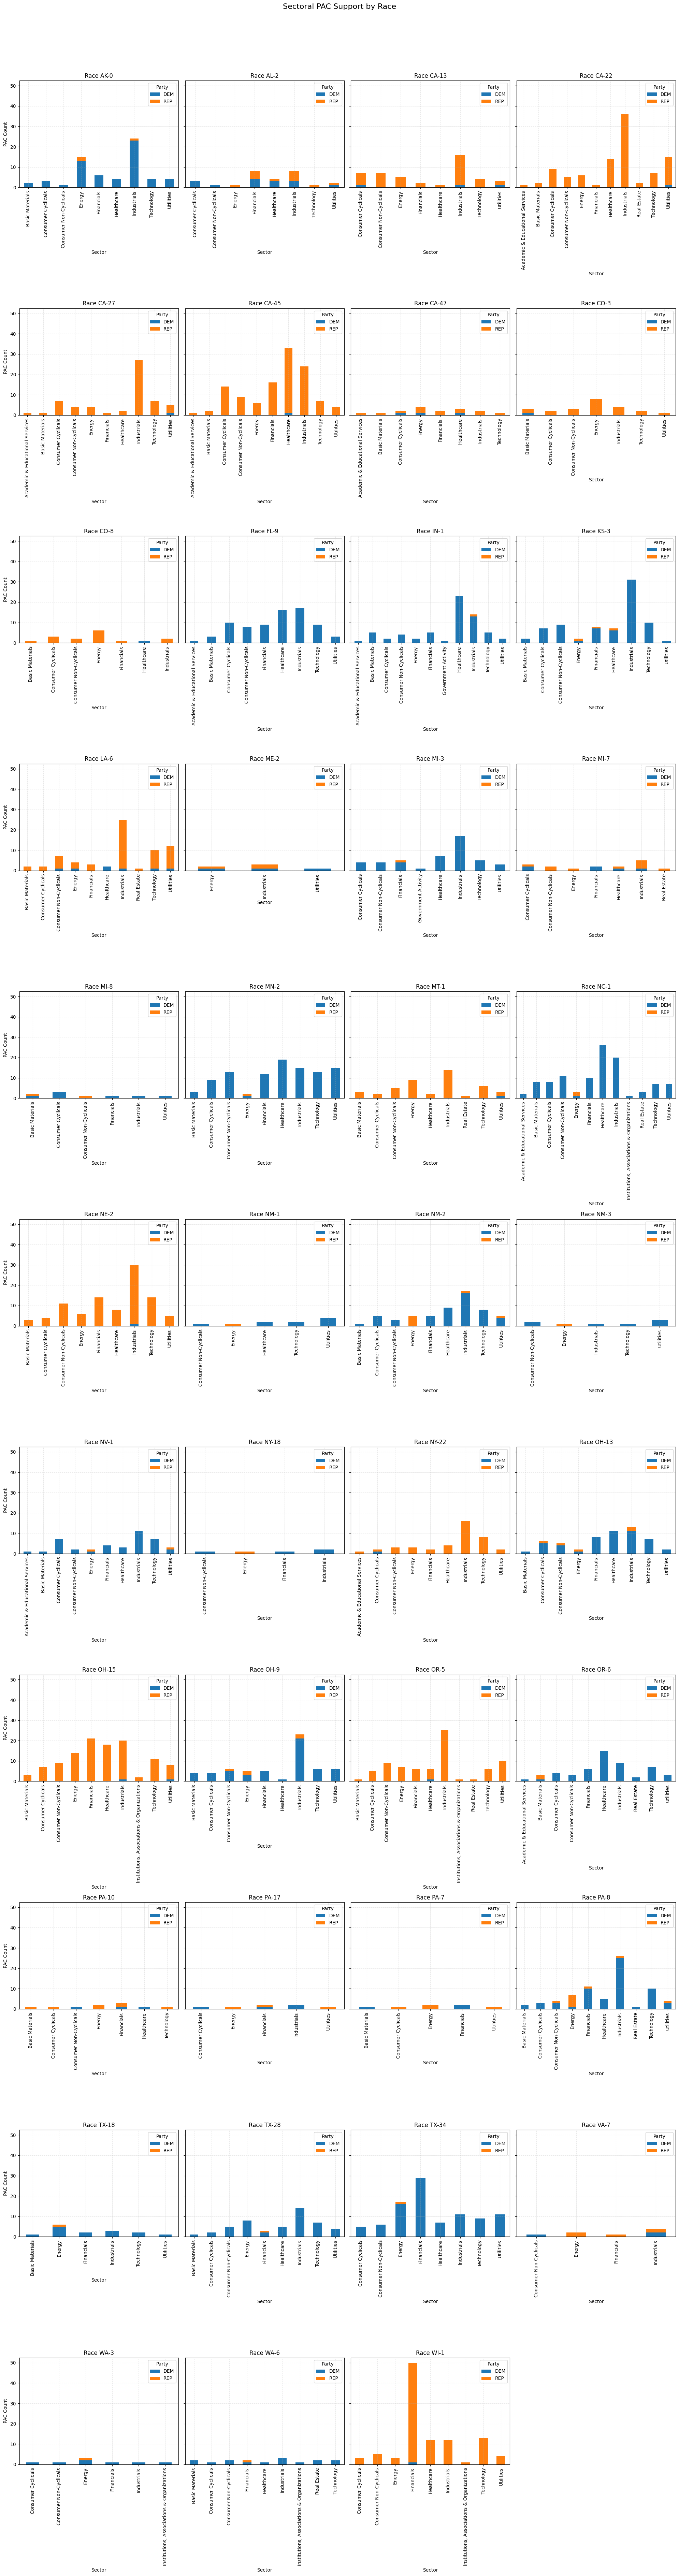

In [252]:
sector_partisan_support = (
    melted_party.groupby(["race_id", "Party", "Sector"], as_index=False)
    .agg(PAC_Count = ("CMTE_ID", "nunique"))
    .reset_index(drop=True)
)
sector_partisan_comp = sector_partisan_support.pivot_table(
    index=["race_id", "Sector"],
    columns="Party",
    values="PAC_Count",
    fill_value=0
).reset_index()

sector_partisan_comp = sector_partisan_comp[sector_partisan_comp["race_id"].isin(valid_races)]

races = sector_partisan_comp["race_id"].unique()

n_races = len(races)
n_cols = 4
n_rows = math.ceil(n_races / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 7 * n_rows), sharey=True)
axes = axes.flatten()

for i, race in enumerate(races):
    ax = axes[i]
    plot_data = sector_partisan_comp[sector_partisan_comp["race_id"] == race].set_index("Sector")
    
    # Only plot if both DEM and REP columns exist
    if {"DEM", "REP"}.issubset(plot_data.columns):
        plot_data[["DEM", "REP"]].plot(kind="bar", stacked=True, ax=ax)
    elif "DEM" in plot_data.columns:
        plot_data[["DEM"]].plot(kind="bar", stacked=True, ax=ax)
    elif "REP" in plot_data.columns:
        plot_data[["REP"]].plot(kind="bar", stacked=True, ax=ax)

    ax.set_title(f"Race {race}")
    ax.set_ylabel("PAC Count")
    ax.grid(True, linestyle="--", alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Sectoral PAC Support by Race", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

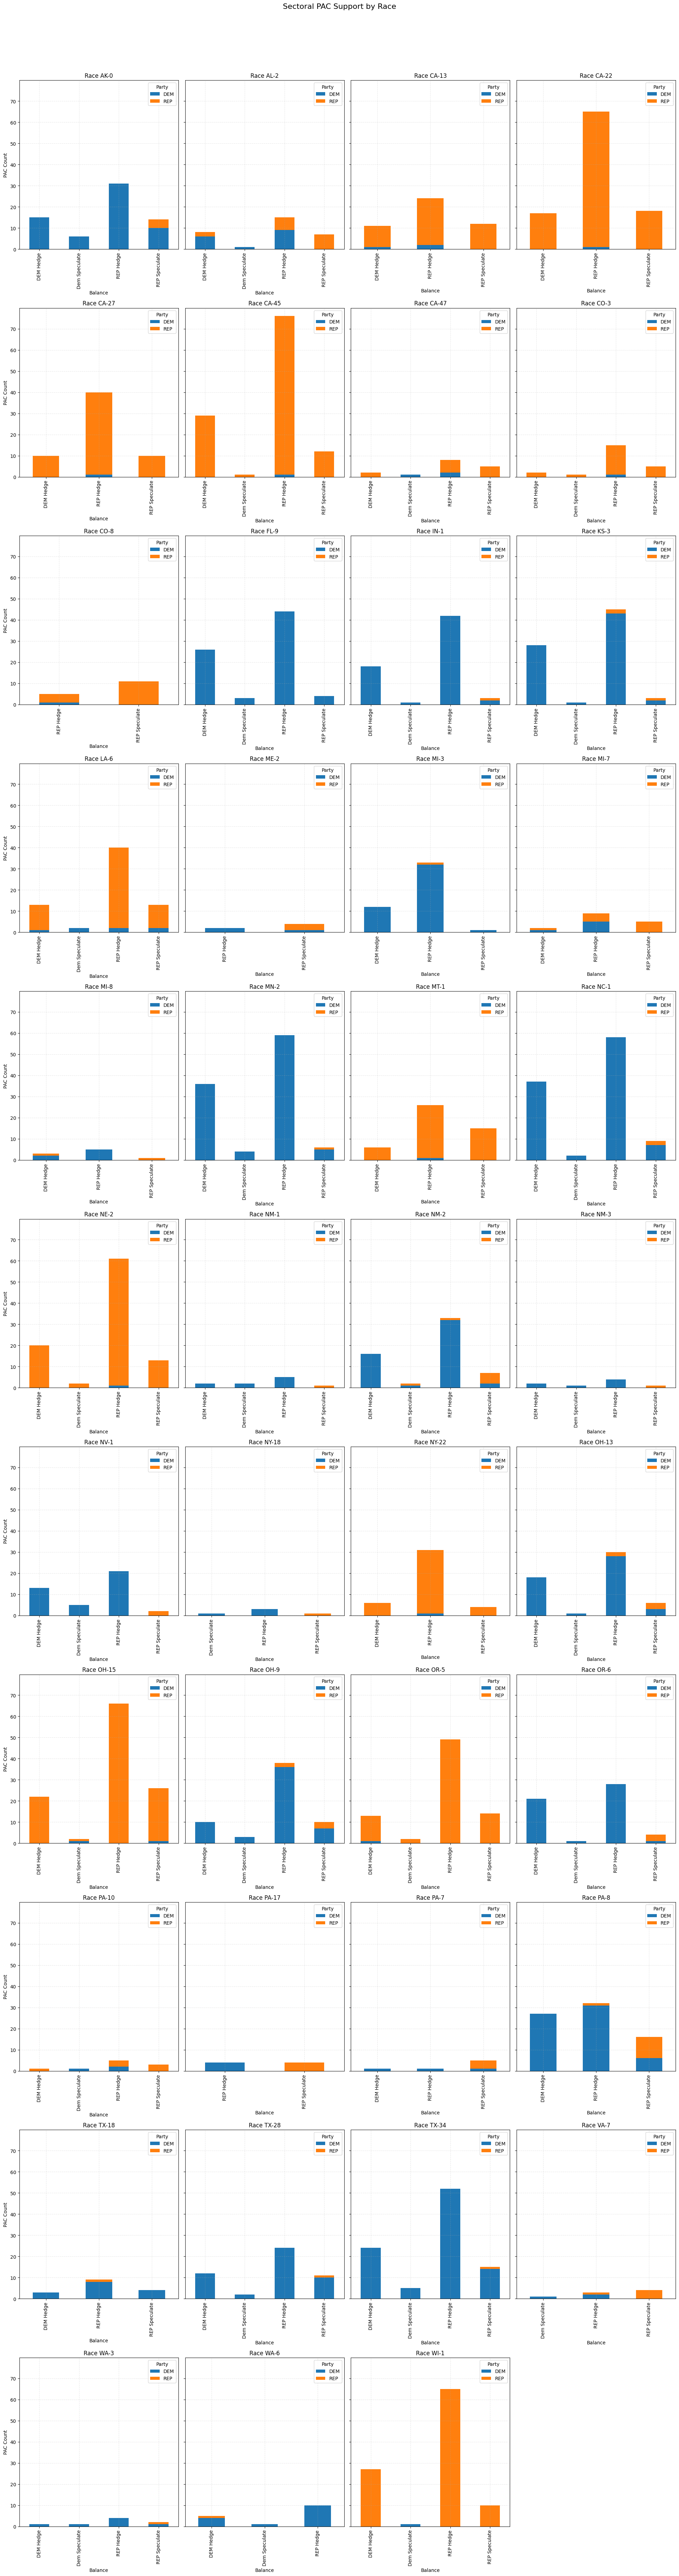

In [ ]:
hedge_partisan_support = (
    melted_party.groupby(["race_id", "Party", "Balance"], as_index=False)
    .agg(PAC_Count = ("CMTE_ID", "nunique"))
    .reset_index(drop=True)
)
hedge_partisan_comp = hedge_partisan_support.pivot_table(
    index=["race_id", "Balance"],
    columns="Party",
    values="PAC_Count",
    fill_value=0
).reset_index()

hedge_partisan_comp = hedge_partisan_comp[hedge_partisan_comp["race_id"].isin(valid_races)]

races = hedge_partisan_comp["race_id"].unique()

n_races = len(races)
n_cols = 4
n_rows = math.ceil(n_races / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 7 * n_rows), sharey=True)
axes = axes.flatten()

for i, race in enumerate(races):
    ax = axes[i]
    plot_data = hedge_partisan_comp[hedge_partisan_comp["race_id"] == race].set_index("Balance")
    
    # Only plot if both DEM and REP columns exist
    if {"DEM", "REP"}.issubset(plot_data.columns):
        plot_data[["DEM", "REP"]].plot(kind="bar", stacked=True, ax=ax)
    elif "DEM" in plot_data.columns:
        plot_data[["DEM"]].plot(kind="bar", stacked=True, ax=ax)
    elif "REP" in plot_data.columns:
        plot_data[["REP"]].plot(kind="bar", stacked=True, ax=ax)

    ax.set_title(f"Race {race}")
    ax.set_ylabel("PAC Count")
    ax.grid(True, linestyle="--", alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("PAC Support by Race", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [254]:
melted_party

,CMTE_ID,race_id,Sector,RIC,house_hedge_count,house_hedge_amount,house_balance_count,house_balance_amount,Party,Supported,Public,Balance
0,C00008748,AK-0,Utilities,SRE.N,0.978723,0.904483,-0.021277,0.095517,DEM,1,Public,DEM Hedge
1,C00009282,AK-0,Industrials,NSC.N,0.895238,0.965517,-0.104762,0.034483,DEM,1,Public,DEM Hedge
2,C00010470,AK-0,Industrials,UNP.N,0.656489,0.558076,-0.343511,-0.441924,DEM,1,Public,REP Hedge
3,C00012245,AK-0,Industrials,NaN,0.974359,0.962766,0.025641,0.037234,DEM,1,Private,DEM Hedge
4,C00024349,AK-0,Industrials,ALK.N,0.709677,0.821705,0.290323,0.178295,DEM,1,Public,DEM Hedge
...,...,...,...,...,...,...,...,...,...,...,...,...
2123,C00693390,WI-1,Healthcare,NaN,0.500000,0.352941,-0.500000,-0.647059,REP,1,Private,REP Speculate
2124,C00719393,WI-1,Consumer Cyclicals,NaN,0.500000,0.545455,-0.500000,-0.454545,REP,1,Private,REP Hedge
2125,C00731000,WI-1,Technology,ABNB.O,1.000000,0.973822,0.000000,-0.026178,REP,1,Public,REP Hedge
2126,C00817395,WI-1,Financials,FITB.O,0.571429,0.558140,-0.428571,-0.441860,REP,1,Public,REP Hedge
